# Skenario 1: MLP Tabular (S1)

**Input:** Data tabular pasien (usia, jenis kelamin, posisi X-ray, nomor follow-up)  
**Model:** Multi-Layer Perceptron (MLP)  
**Output:** Klasifikasi biner — Normal (0) vs Abnormal (1)  
**Tujuan:** Baseline performance menggunakan metadata klinis saja, tanpa citra X-ray

Notebook ini menggunakan arsitektur `TabularMLP` dari `src/models/architectures.py`.

In [1]:
import sys
sys.path.insert(0, r"D:\TA\nih-multimodal")

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score, f1_score,
    confusion_matrix, roc_curve, accuracy_score
)

from configs.config import cfg
from src.models.architectures import TabularMLP
from src.data.dataset import build_image_index, load_and_prepare_metadata, patient_level_split

# Reproducibility
torch.manual_seed(cfg.train.seed)
np.random.seed(cfg.train.seed)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_DIR  = cfg.paths.figures_dir
CKPT_DIR  = cfg.paths.checkpoint_dir
CKPT_DIR.mkdir(parents=True, exist_ok=True)
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Device  : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"PyTorch : {torch.__version__}")

Device  : cuda
GPU     : NVIDIA GeForce RTX 3060 Laptop GPU
VRAM    : 6.4 GB
PyTorch : 2.5.1+cu121


## 1. Load Data (Patient-Level Split — NIH Official Lists)

In [2]:
TABULAR_COLS = ["Patient Age", "gender_encoded", "view_PA", "Follow-up #"]

# Patient-level split using official NIH lists — identical to S2/S3/S4
image_index = build_image_index(cfg.paths.image_dirs)
df = load_and_prepare_metadata(cfg.paths.csv_path, image_index)
df_train, df_val, df_test = patient_level_split(
    df,
    cfg.paths.train_list_path,
    cfg.paths.test_list_path,
    val_ratio=cfg.data.val_ratio,
    seed=cfg.train.seed,
)

# Extract tabular arrays directly — no image loading needed for S1
X_train = df_train[TABULAR_COLS].values.astype(np.float32)
X_val   = df_val[TABULAR_COLS].values.astype(np.float32)
X_test  = df_test[TABULAR_COLS].values.astype(np.float32)

y_train = df_train["binary_label"].values.astype(np.float32)
y_val   = df_val["binary_label"].values.astype(np.float32)
y_test  = df_test["binary_label"].values.astype(np.float32)

# Fit StandardScaler on train only (consistent with NIHChestXrayDataset in S2/S3/S4)
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

print(f"[Data] Split — Train: {len(y_train):,} | Val: {len(y_val):,} | Test: {len(y_test):,}")
print(f"Fitur tabular  : {X_train.shape[1]} kolom")
print(f"Train Normal   : {int((y_train==0).sum()):,} | Abnormal : {int((y_train==1).sum()):,}")
print(f"Val   Normal   : {int((y_val==0).sum()):,}   | Abnormal : {int((y_val==1).sum()):,}")
print(f"Test  Normal   : {int((y_test==0).sum()):,}  | Abnormal : {int((y_test==1).sum()):,}")

# pos_weight for slight class-balance correction — same formula as S2/S3
pos_ratio  = y_train.mean()
pos_weight = torch.tensor([(1 - pos_ratio) / pos_ratio], dtype=torch.float32).to(DEVICE)
print(f"\nPos ratio (train) : {pos_ratio:.3f}")
print(f"BCEWithLogits pos_weight : {pos_weight.item():.3f}")

[Data] Split — Train: 77,994 | Val: 8,530 | Test: 25,596
Fitur tabular  : 4 kolom
Train Normal   : 45,490 | Abnormal : 32,504
Val   Normal   : 5,010   | Abnormal : 3,520
Test  Normal   : 9,861  | Abnormal : 15,735

Pos ratio (train) : 0.417
BCEWithLogits pos_weight : 1.400


## 2. PyTorch Dataset & DataLoader

In [3]:
class TabularDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self) -> int:
        return len(self.y)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]


# batch_size consistent with cfg (16), same as S2/S3/S4
BATCH_SIZE = cfg.train.batch_size

train_ds = TabularDataset(X_train, y_train)
val_ds   = TabularDataset(X_val,   y_val)
test_ds  = TabularDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE * 2, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE * 2, shuffle=False)

print(f"Batch size     : {BATCH_SIZE}")
print(f"Train batches  : {len(train_loader)}")
print(f"Val batches    : {len(val_loader)}")
print(f"Test batches   : {len(test_loader)}")

Batch size     : 16
Train batches  : 4874
Val batches    : 267
Test batches   : 800


## 3. Model, Optimizer, Scheduler

In [4]:
# S1: binary output (num_classes=1)
model = TabularMLP(num_classes=1).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=cfg.train.lr_tabular,
    weight_decay=cfg.train.weight_decay
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=cfg.train.scheduler_patience,
    factor=cfg.train.scheduler_factor, verbose=True
)

total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model          : TabularMLP (S1 Binary)")
print(f"Total params   : {total_params:,}")
print(f"Trainable      : {trainable_params:,}")
print(f"LR (tabular)   : {cfg.train.lr_tabular}")
print(model)

Model          : TabularMLP (S1 Binary)
Total params   : 25,665
Trainable      : 25,665
LR (tabular)   : 0.001
TabularMLP(
  (branch): TabularBranch(
    (encoder): Sequential(
      (0): Linear(in_features=4, out_features=64, bias=True)
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Dropout(p=0.3, inplace=False)
      (4): Linear(in_features=64, out_features=128, bias=True)
      (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU(inplace=True)
      (7): Dropout(p=0.3, inplace=False)
      (8): Linear(in_features=128, out_features=128, bias=True)
      (9): ReLU(inplace=True)
    )
  )
  (classifier): Linear(in_features=128, out_features=1, bias=True)
)


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


## 4. Training Loop

In [5]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, n = 0.0, 0
    all_probs, all_labels = [], []

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(tabular=X_batch).squeeze(1)
        loss = criterion(logits, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * len(y_batch)
        n += len(y_batch)
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        all_probs.append(probs)
        all_labels.append(y_batch.cpu().numpy())

    all_probs  = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    auc = roc_auc_score(all_labels, all_probs)
    return total_loss / n, auc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, n = 0.0, 0
    all_probs, all_labels = [], []

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = model(tabular=X_batch).squeeze(1)
        loss = criterion(logits, y_batch)

        total_loss += loss.item() * len(y_batch)
        n += len(y_batch)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(y_batch.cpu().numpy())

    all_probs  = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    auc = roc_auc_score(all_labels, all_probs)
    return total_loss / n, auc, all_probs, all_labels


# Training loop with early stopping
NUM_EPOCHS    = cfg.train.num_epochs
PATIENCE      = cfg.train.early_stop_patience
CKPT_PATH     = CKPT_DIR / "model_s1_mlp_tabular.pt"

history = {"train_loss": [], "val_loss": [], "train_auc": [], "val_auc": []}
best_val_auc = 0.0
patience_counter = 0
t0 = time.time()

print(f"{'Epoch':>5} {'Train Loss':>12} {'Train AUC':>10} {'Val Loss':>10} {'Val AUC':>9} {'LR':>10} {'Time':>7}")
print("-" * 70)

for epoch in range(1, NUM_EPOCHS + 1):
    ep_start = time.time()

    train_loss, train_auc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_auc, _, _ = evaluate(model, val_loader, criterion, DEVICE)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_auc"].append(train_auc)
    history["val_auc"].append(val_auc)

    scheduler.step(val_auc)
    current_lr = optimizer.param_groups[0]["lr"]
    ep_time = time.time() - ep_start

    flag = ""
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), CKPT_PATH)
        patience_counter = 0
        flag = " ✓"
    else:
        patience_counter += 1

    print(f"{epoch:>5} {train_loss:>12.4f} {train_auc:>10.4f} "
          f"{val_loss:>10.4f} {val_auc:>9.4f} {current_lr:>10.2e} "
          f"{ep_time:>6.1f}s{flag}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch} (patience={PATIENCE})")
        break

total_time = time.time() - t0
print(f"\nTraining selesai dalam {total_time/60:.1f} menit")
print(f"Best Val AUC : {best_val_auc:.4f}")
print(f"Model tersimpan: {CKPT_PATH}")

Epoch   Train Loss  Train AUC   Val Loss   Val AUC         LR    Time
----------------------------------------------------------------------
    1       0.7897     0.6049     0.7802    0.6273   1.00e-03   15.3s ✓
    2       0.7870     0.6111     0.7825    0.6244   1.00e-03   14.8s
    3       0.7866     0.6114     0.7790    0.6275   1.00e-03   19.4s ✓
    4       0.7866     0.6120     0.7800    0.6278   1.00e-03   24.9s ✓
    5       0.7856     0.6141     0.7813    0.6285   1.00e-03   24.3s ✓
    6       0.7853     0.6145     0.7799    0.6254   1.00e-03   24.7s
    7       0.7853     0.6144     0.7776    0.6282   1.00e-03   23.5s
    8       0.7855     0.6143     0.7827    0.6303   1.00e-03   15.0s ✓
    9       0.7853     0.6140     0.7776    0.6283   1.00e-03   14.2s
   10       0.7854     0.6143     0.7807    0.6289   1.00e-03   14.2s
   11       0.7846     0.6161     0.7812    0.6248   1.00e-03   13.8s
   12       0.7848     0.6154     0.7789    0.6280   5.00e-04   14.8s
   13    

## 5. Training Curves

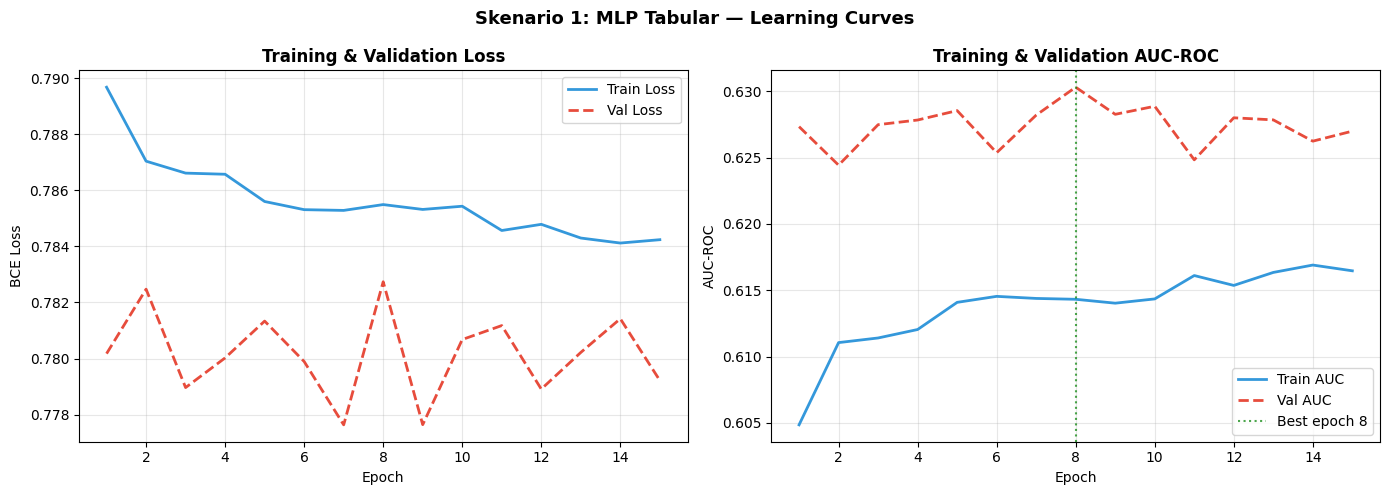

Disimpan → results/figures/s1_training_curves.png


In [6]:
epochs_ran = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs_ran, history["train_loss"], label="Train Loss", color="#3498db", linewidth=2)
axes[0].plot(epochs_ran, history["val_loss"],   label="Val Loss",   color="#e74c3c", linewidth=2, linestyle="--")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].set_title("Training & Validation Loss", fontweight="bold")
axes[0].legend()
axes[0].grid(alpha=0.3)

# AUC
axes[1].plot(epochs_ran, history["train_auc"], label="Train AUC", color="#3498db", linewidth=2)
axes[1].plot(epochs_ran, history["val_auc"],   label="Val AUC",   color="#e74c3c", linewidth=2, linestyle="--")
best_ep = np.argmax(history["val_auc"]) + 1
axes[1].axvline(best_ep, color="green", linestyle=":", alpha=0.7, label=f"Best epoch {best_ep}")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("AUC-ROC")
axes[1].set_title("Training & Validation AUC-ROC", fontweight="bold")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Skenario 1: MLP Tabular — Learning Curves", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR / "s1_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Disimpan → results/figures/s1_training_curves.png")

## 6. Evaluasi pada Test Set

In [7]:
# Load best checkpoint
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
_, test_auc, test_probs, test_labels = evaluate(model, test_loader, criterion, DEVICE)

# Threshold = 0.5
test_preds = (test_probs >= 0.5).astype(int)

acc  = accuracy_score(test_labels, test_preds)
f1   = f1_score(test_labels, test_preds, average="binary")
f1_macro = f1_score(test_labels, test_preds, average="macro")
auc  = roc_auc_score(test_labels, test_probs)

print("=" * 55)
print("HASIL EVALUASI SKENARIO 1: MLP TABULAR")
print("=" * 55)
print(f"Accuracy       : {acc:.4f}")
print(f"F1-Score (bin) : {f1:.4f}")
print(f"F1-Score (mac) : {f1_macro:.4f}")
print(f"AUC-ROC        : {auc:.4f}")
print()
print(classification_report(test_labels, test_preds, target_names=["Normal", "Abnormal"]))

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18964\3035501062.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVI

HASIL EVALUASI SKENARIO 1: MLP TABULAR
Accuracy       : 0.6559
F1-Score (bin) : 0.7659
F1-Score (mac) : 0.5586
AUC-ROC        : 0.6185

              precision    recall  f1-score   support

      Normal       0.64      0.24      0.35      9861
    Abnormal       0.66      0.92      0.77     15735

    accuracy                           0.66     25596
   macro avg       0.65      0.58      0.56     25596
weighted avg       0.65      0.66      0.61     25596



## 7. Confusion Matrix & ROC Curve

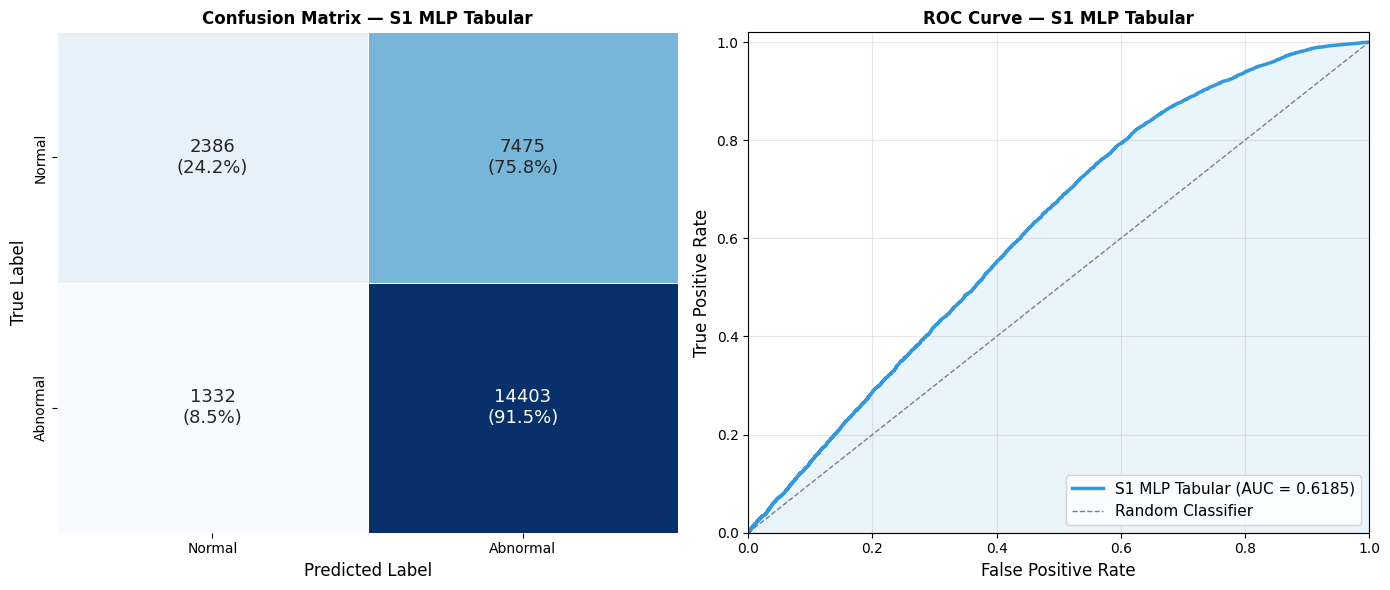

Disimpan → results/figures/s1_confusion_roc.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Confusion Matrix ──
cm = confusion_matrix(test_labels, test_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

annot = np.array([[f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)" for j in range(2)] for i in range(2)])
sns.heatmap(cm, annot=annot, fmt="", cmap="Blues", ax=axes[0],
            xticklabels=["Normal", "Abnormal"], yticklabels=["Normal", "Abnormal"],
            linewidths=0.5, cbar=False, annot_kws={"size": 13})
axes[0].set_xlabel("Predicted Label", fontsize=12)
axes[0].set_ylabel("True Label", fontsize=12)
axes[0].set_title("Confusion Matrix — S1 MLP Tabular", fontweight="bold")

# ── ROC Curve ──
fpr, tpr, thresholds = roc_curve(test_labels, test_probs)
axes[1].plot(fpr, tpr, color="#3498db", linewidth=2.5, label=f"S1 MLP Tabular (AUC = {auc:.4f})")
axes[1].plot([0, 1], [0, 1], "--", color="gray", linewidth=1, label="Random Classifier")
axes[1].fill_between(fpr, tpr, alpha=0.1, color="#3498db")
axes[1].set_xlabel("False Positive Rate", fontsize=12)
axes[1].set_ylabel("True Positive Rate", fontsize=12)
axes[1].set_title("ROC Curve — S1 MLP Tabular", fontweight="bold")
axes[1].legend(loc="lower right", fontsize=11)
axes[1].grid(alpha=0.3)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig(SAVE_DIR / "s1_confusion_roc.png", dpi=150, bbox_inches="tight")
plt.show()
print("Disimpan → results/figures/s1_confusion_roc.png")

## 8. Simpan Hasil Evaluasi

In [9]:
TABLES_DIR = cfg.paths.project_root / "results" / "tables"
TABLES_DIR.mkdir(parents=True, exist_ok=True)

results_s1 = {
    "Skenario"   : "S1",
    "Model"      : "MLP Tabular",
    "Input"      : "Tabular (4 fitur)",
    "Accuracy"   : round(acc, 4),
    "F1 (Binary)": round(f1, 4),
    "F1 (Macro)" : round(f1_macro, 4),
    "AUC-ROC"    : round(auc, 4),
    "Best Epoch" : best_ep,
    "Best Val AUC": round(best_val_auc, 4),
}

df_results = pd.DataFrame([results_s1])
df_results.to_csv(TABLES_DIR / "results_s1.csv", index=False)

# Simpan juga prediksi (prob) untuk komparasi antar skenario nanti
pd.DataFrame({
    "true_label" : test_labels.astype(int),
    "prob_s1"    : test_probs,
    "pred_s1"    : test_preds,
}).to_csv(TABLES_DIR / "predictions_s1.csv", index=False)

print("Tersimpan:")
print(f"  {TABLES_DIR / 'results_s1.csv'}")
print(f"  {TABLES_DIR / 'predictions_s1.csv'}")
print()
print(df_results.to_string(index=False))

Tersimpan:
  D:\TA\nih-multimodal\results\tables\results_s1.csv
  D:\TA\nih-multimodal\results\tables\predictions_s1.csv

Skenario       Model             Input  Accuracy  F1 (Binary)  F1 (Macro)  AUC-ROC  Best Epoch  Best Val AUC
      S1 MLP Tabular Tabular (4 fitur)    0.6559       0.7659      0.5586   0.6185           8        0.6303


## 9. Ringkasan Skenario 1

| Metrik | Nilai |
|--------|-------|
| Accuracy | 0.6559 |
| F1-Score (Binary) | 0.7659 |
| F1-Score (Macro) | 0.5586 |
| AUC-ROC | 0.6185 |
| Best Val AUC | 0.6303 (epoch 8) |

> **Interpretasi:** Model MLP tabular menggunakan 4 fitur demografi pasien (usia, jenis kelamin, posisi pengambilan X-ray, nomor follow-up) sebagai baseline. AUC-ROC 0.6185 menunjukkan fitur tabular saja memiliki kemampuan diskriminasi terbatas untuk membedakan Normal vs Abnormal. Performa ini akan dibandingkan dengan Skenario 2 (CNN gambar) dan Skenario 3 (multimodal fusion) pada test set yang identik (25.596 gambar, patient-level split NIH resmi).

**Artefak yang dihasilkan:**
- `results/checkpoints/model_s1_mlp_tabular.pt` — bobot model terbaik
- `results/figures/s1_training_curves.png` — kurva training
- `results/figures/s1_confusion_roc.png` — confusion matrix + ROC curve
- `results/tables/results_s1.csv` — tabel metrik evaluasi
- `results/tables/predictions_s1.csv` — probabilitas prediksi (untuk komparasi S1–S4)